In [ ]:
import numpy as np

def aaa(F, Z, tol=1e-13, mmax=100):
    """
    AAA algorithm for rational approximation.
    Based on Chebfun's AAA implementation (Nakatsukasa, Sete, and Trefethen, 2018).

    Args:
        F: Callable analytic function.
        Z: Array of sample points in the complex plane.
        tol: Tolerance for termination.
        mmax: Maximum number of iterations.

    Returns:
        r: Rational approximation (callable function).
        z: Support points.
        f: Function values at support points.
        w: Barycentric weights.
        err: Error history.
    """
    M = len(Z)
    FZ = F(Z)
    J = np.arange(M)
    R = np.mean(FZ) * np.ones(M)
    err = []
    S = []

    for m in range(mmax):
        # Pick next support point: where residual is largest
        j = np.argmax(np.abs(FZ - R))
        S.append(j)
        J = np.delete(np.arange(M), S)

        # Build Cauchy matrix C_{jk} = 1 / (Z_j - Z_Sk)
        ZS = Z[S]
        FS = FZ[S]
        C = 1 / (Z[J, None] - ZS[None, :])

        # Solve least squares for weights w
        A = C * (FS[None, :] - FZ[J, None])
        U, s, Vh = np.linalg.svd(A, full_matrices=False)
        w = Vh[-1, :]

        # Define rational approximant
        def rfun(z_eval):
            num = np.sum(w * FS / (z_eval[:, None] - ZS[None, :]), axis=1)
            den = np.sum(w / (z_eval[:, None] - ZS[None, :]), axis=1)
            return num / den

        R = rfun(Z)
        err_m = np.max(np.abs(FZ - R))
        err.append(err_m)

        if err_m < tol:
            break

    z = Z[S]
    f = FZ[S]
    return rfun, z, f, w, err


/tmp/ipython-input-3078164412.py:46: RuntimeWarning: divide by zero encountered in divide
  num = np.sum(w * FS / (z_eval[:, None] - ZS[None, :]), axis=1)
/tmp/ipython-input-3078164412.py:46: RuntimeWarning: invalid value encountered in divide
  num = np.sum(w * FS / (z_eval[:, None] - ZS[None, :]), axis=1)
/tmp/ipython-input-3078164412.py:47: RuntimeWarning: divide by zero encountered in divide
  den = np.sum(w / (z_eval[:, None] - ZS[None, :]), axis=1)
/tmp/ipython-input-3078164412.py:47: RuntimeWarning: invalid value encountered in divide
  den = np.sum(w / (z_eval[:, None] - ZS[None, :]), axis=1)
/tmp/ipython-input-3078164412.py:48: RuntimeWarning: invalid value encountered in divide
  return num / den
/tmp/ipython-input-3078164412.py:48: RuntimeWarning: divide by zero encountered in divide
  return num / den


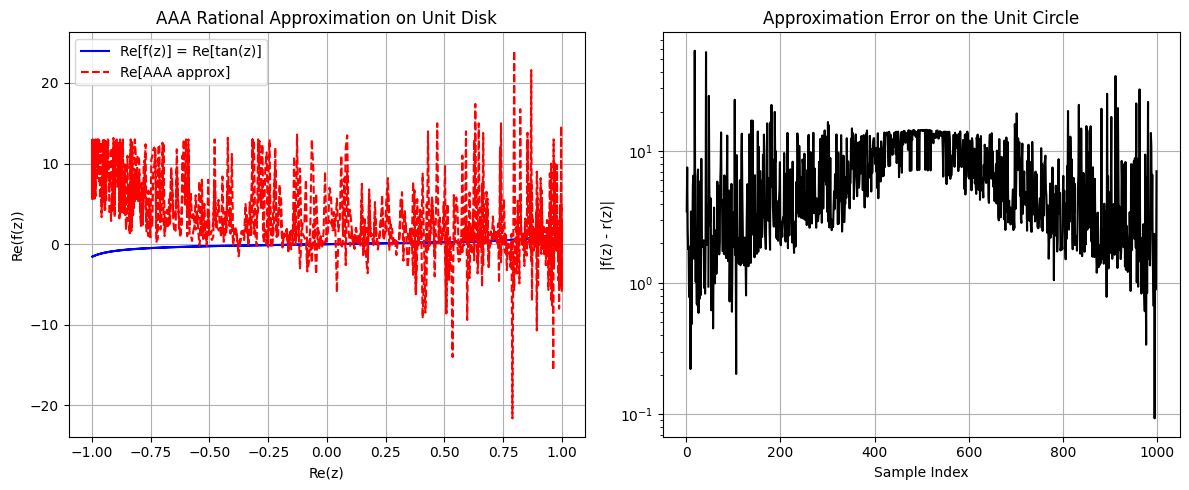

Number of support points used: 100
Final max error: nan


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Analytic function in the unit disk
# -----------------------------------------------------------

M = 128
Z = np.exp(1j * 2 * np.pi * np.arange(M) / M)   # 128 points on the unit circle
F = lambda z: np.tan(z)                         # target function

# Compute AAA approximation (requires aaa() function)
r, z, f, w, err = aaa(F, Z)

# Evaluate error on dense test grid
Ztest = np.exp(1j * np.linspace(0, 2*np.pi, 1000))
error = np.abs(F(Ztest) - r(Ztest))

# -----------------------------------------------------------
# Plot results
# -----------------------------------------------------------

plt.figure(figsize=(12,5))

# --- Left subplot: function vs approximation
plt.subplot(1, 2, 1)
plt.plot(np.real(Ztest), np.real(F(Ztest)), 'b', label='Re[f(z)] = Re[tan(z)]')
plt.plot(np.real(Ztest), np.real(r(Ztest)), '--r', label='Re[AAA approx]')
plt.title('AAA Rational Approximation on Unit Disk')
plt.xlabel('Re(z)'); plt.ylabel('Re(f(z))')
plt.legend()
plt.grid(True)

# --- Right subplot: approximation error
plt.subplot(1, 2, 2)
plt.semilogy(np.arange(len(Ztest)), error, 'k')
plt.title('Approximation Error on the Unit Circle')
plt.xlabel('Sample Index')
plt.ylabel('|f(z) - r(z)|')
plt.grid(True)

plt.tight_layout()
plt.show()

# Print result summary
print(f"Number of support points used: {len(z)}")
print(f"Final max error: {err[-1]:.3e}")